# Relaxing a spin spiral: `dE/dq`

The spiral wavevector is a coordinate of the calculation exactly as an atomic position is,
so it gets the same treatment: write the total energy as a function of `q` at **frozen**
wavefunctions, take `jax.grad`, and walk downhill with the same BFGS. A hydrogen chain
started at `q = 0.30` finds its antiferromagnetic ground state at **0.50003 in six SCF
runs**.

`pw.x` has no spiral, so as in notebook 12 the validation is identities and finite
differences. **Only two terms of the energy depend on `q`** — $|k \pm q/2 + G|^2$ and
$v_{kb}(k \pm q/2)$ — because at frozen coefficients the rotated-frame density is lattice
periodic on an FFT box that does not move. Phase P21.

In [1]:
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso.forces.energy import state_from_result
from pypresso.forces.spiral import compute_spiral_gradient, spiral_energy
from pypresso.io.pwin import parse_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.system import build_system
from pypresso.workflows.spiral import relax_spiral_q, run_spiral_scan

PSEUDO, GENERATED = Path("../tests/data/pseudo"), Path("../tests/data/qe")
CHAIN = (GENERATED / "h-chain-spiral.in").read_text()


def chain_at(q3, ecutwfc=25.0):
    text = CHAIN.replace("spiral_q(3) = 0.25", f"spiral_q(3) = {q3}")
    text = text.replace("ecutwfc = 25.0", f"ecutwfc = {ecutwfc}")
    system = build_system(parse_pw_input(text))
    return system, tuple(read_upf(PSEUDO / s.pseudo_file)
                         for s in system.structure.species)


def converge(q3, ecutwfc=25.0):
    system, pseudos = chain_at(q3, ecutwfc)
    calculation = Calculation(system, pseudos)
    return calculation, run_scf(system, pseudos, calculation=calculation, conv_thr=1e-12,
                                mixing_beta=0.3, max_iterations=300)


calculation, result = converge(0.3)
gradient = compute_spiral_gradient(calculation, result)

# The identity that has to hold before the derivative means anything: the functional being
# differentiated *is* the total energy at the converged state.
print("spiral_energy at the converged state  %.14f Ry" % gradient.total_energy)
print("the SCF's own total energy            %.14f Ry" % result.total_energy)
print("difference                            %.1e Ry"
      % (gradient.total_energy - result.total_energy))
print("\ndE/dq (lattice coordinates)   %s" % np.round(gradient.gradient, 8))
print("the chain runs along z, so the transverse components are zero by symmetry: %.1e"
      % np.abs(gradient.gradient[:2]).max())

spiral_energy at the converged state  -0.95523772122865 Ry
the SCF's own total energy            -0.95523772122865 Ry
difference                            1.1e-15 Ry

dE/dq (lattice coordinates)   [ 0.         -0.         -0.01090176]
the chain runs along z, so the transverse components are zero by symmetry: 6.3e-11


## Two finite differences, checking two different things

The first differentiates the **functional** — same frozen state, `q` moved by hand — and
tests the gradient itself. The second moves `q` and **re-converges the SCF**, testing the
stationarity that lets the wavefunctions be frozen at all. The sphere is held fixed for
it: sphere membership is piecewise constant in `q`, so freezing it is exact between the
wavevectors where a plane wave crosses the cutoff.

In [2]:
state = state_from_result(result)
q0, delta = np.asarray(calculation.system.spiral_q, dtype=float), 1e-5
plus, minus = q0.copy(), q0.copy()
plus[2] += delta
minus[2] -= delta
finite = (float(spiral_energy(calculation, jnp.asarray(plus), state))
          - float(spiral_energy(calculation, jnp.asarray(minus), state))) / (2 * delta)
print("differentiating the functional:  finite difference %.12f   jax.grad %.12f   (%.1e)"
      % (finite, gradient.gradient[2], finite - gradient.gradient[2]))

_, pseudos = chain_at(0.3)
print("\n%8s %20s %20s %13s"
      % ("delta", "re-converged FD", "jax.grad", "difference"))
for step in (0.04, 0.02):
    energies = []
    for shift in (step, -step):
        moved = calculation.at_spiral_q(jnp.asarray([0.0, 0.0, 0.3 + shift]),
                                        rebuild_basis=False)
        energies.append(run_scf(moved.system, pseudos, calculation=moved, conv_thr=1e-12,
                                mixing_beta=0.3, max_iterations=300).total_energy)
    finite = (energies[0] - energies[1]) / (2 * step)
    print("%8.3f %20.12f %20.12f %13.1e"
          % (step, finite, gradient.gradient[2], finite - gradient.gradient[2]))

differentiating the functional:  finite difference -0.010901763214   jax.grad -0.010901763190   (-2.4e-11)

   delta      re-converged FD             jax.grad    difference


   0.040      -0.010695946507      -0.010901763190       2.1e-04


   0.020      -0.010849971652      -0.010901763190       5.2e-05


**What the frozen sphere costs.** Rebuilding it makes `E(q)` jump slightly where a plane
wave crosses the cutoff, and that jump is the Pulay error of a finite basis. Measured
against a sphere-rebuilding finite difference: **8.3e-4 Ry per unit `q` at
`ecutwfc = 25`, 5.8e-4 at 40, 8.3e-6 at 60** — erratic rather than smoothly convergent,
because it counts the crossings inside one window rather than truncating a series. (Run
offline; it is nine SCF runs.)

## Symmetry pins two wavevectors exactly

In [3]:
for q3 in (0.0, 0.5):
    c, r = converge(q3)
    g = compute_spiral_gradient(c, r)
    print("q3 = %4.1f   E = %.10f Ry   |m| = %.4f mu_B   max |dE/dq| = %.1e"
          % (q3, r.total_energy, np.linalg.norm(r.magnetization_vector),
             np.abs(g.gradient).max()))

q3 =  0.0   E = -0.9540418305 Ry   |m| = 0.0000 mu_B   max |dE/dq| = 4.5e-11


q3 =  0.5   E = -0.9567796407 Ry   |m| = 0.6144 mu_B   max |dE/dq| = 8.1e-09


Not to within a tolerance — to round-off. $q$ and $-q$ are the same spiral mirrored, so
the energy is even about both and its slope has to vanish there.

## Downhill

BFGS on the reciprocal cell, so that its metric is $b_i \cdot b_j$. **The trap:** BFGS's
initial inverse Hessian is right for atoms because a chemical bond is about 1 Ry/bohr²,
and it is two orders of magnitude out on a milli-Rydberg magnetic surface — so
`BFGSSettings.hessian_scale` sets the first step to the trust radius instead.

In [4]:
system, pseudos = chain_at(0.30, ecutwfc=40.0)
relaxed = relax_spiral_q(system, pseudos, mixing_beta=0.3, free=(0, 0, 1), nstep=20)

print("%5s %10s %16s %13s %8s" % ("step", "q3", "E (Ry)", "max |dE/dq|", "SCF its"))
for step in relaxed.steps:
    print("%5d %10.5f %16.10f %13.2e %8d"
          % (step.index, step.wavevector[2], step.total_energy, step.max_gradient,
             step.scf_iterations))
print("\nconverged = %s   q = %s   (the answer it had to find is q3 = 0.5)"
      % (relaxed.converged, np.round(relaxed.wavevector, 6)))

 step         q3           E (Ry)   max |dE/dq|  SCF its
    1    0.30000    -0.9620586875      5.08e-03        9
    2    0.34463    -0.9625849398      4.76e-03        6
    3    0.39372    -0.9630968967      3.77e-03        6
    4    0.46736    -0.9635797030      1.29e-03        6
    5    0.50563    -0.9636328653      2.21e-04        4
    6    0.50003    -0.9636298145      1.32e-06        4

converged = True   q = [0.       0.       0.500026]   (the answer it had to find is q3 = 0.5)


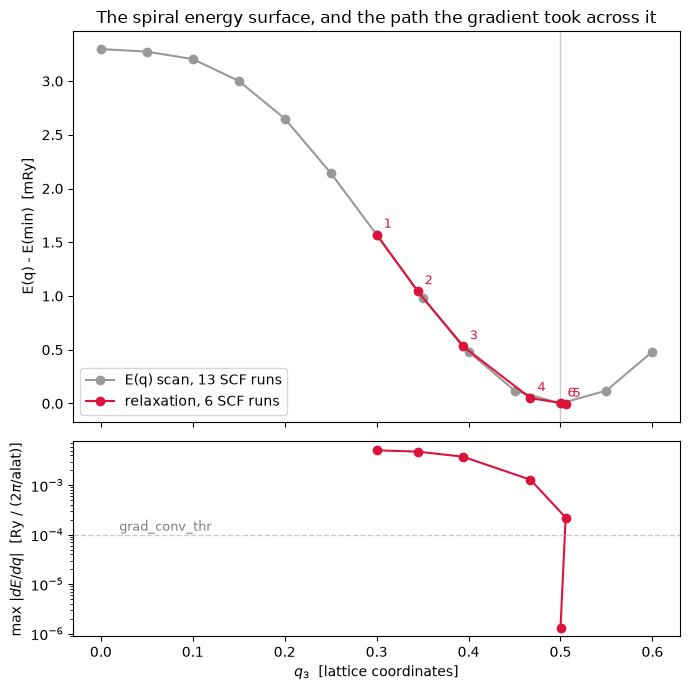

In [5]:
scan_q = np.linspace(0.0, 0.6, 13)
scan = run_spiral_scan(chain_at(0.0, ecutwfc=40.0)[0], pseudos,
                       np.column_stack([np.zeros_like(scan_q), np.zeros_like(scan_q),
                                        scan_q]),
                       conv_thr=1e-10, mixing_beta=0.3, max_iterations=300)

fig, (top, bottom) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                                  gridspec_kw={"height_ratios": [2, 1]})
reference = scan.energies.min()
top.plot(scan_q, 1e3 * (scan.energies - reference), "o-", color="0.6",
         label="E(q) scan, %d SCF runs" % len(scan_q))
path = np.array([[s.wavevector[2], s.total_energy] for s in relaxed.steps])
top.plot(path[:, 0], 1e3 * (path[:, 1] - reference), "o-", color="crimson",
         label="relaxation, %d SCF runs" % relaxed.nsteps)
for index, (q3, energy) in enumerate(path, start=1):
    top.annotate(str(index), (q3, 1e3 * (energy - reference)), textcoords="offset points",
                 xytext=(5, 5), color="crimson", fontsize=9)
top.axvline(0.5, color="0.8", lw=1, zorder=0)
top.set_ylabel("E(q) - E(min)  [mRy]"); top.legend()
top.set_title("The spiral energy surface, and the path the gradient took across it")

bottom.plot(path[:, 0], [s.max_gradient for s in relaxed.steps], "o-", color="crimson")
bottom.axhline(1e-4, color="0.8", lw=1, ls="--")
bottom.set_yscale("log"); bottom.set_xlabel("$q_3$  [lattice coordinates]")
bottom.set_ylabel(r"max $|dE/dq|$  [Ry / (2$\pi$/alat)]")
bottom.annotate("grad_conv_thr", (0.02, 1.2e-4), color="0.5", fontsize=9)
fig.tight_layout()

The relaxation reaches the minimum in a fraction of the runs the scan needs, and it does
not need to know the answer is on the axis — the gradient is a vector and the two
transverse components are free to move if the physics asks them to.

**A magnetic field is refused here.** Its energy is outside the reported total (notebook
11), so the state would be stationary for a different functional than the one being
differentiated.

---
**The detail:** `PLAN.md` §3 P21 — which of the seven energy terms carry `q` and why the
gradient never differentiates through an FFT, and the compiled-gradient trap (it closes
over its sphere, so it is dropped on every `at_spiral_q`).
**The tests:** `tests/regression/test_spiral_relaxation.py`.